In [ ]:
# imports 
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
#loading dataset
dataset = load_dataset("fancyzhx/ag_news")
dataset

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 2518305.45 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [ ]:
# size of both the sets
print( 'Training examples :',len(dataset['train']))
print('Testing examples :',len(dataset['test']))

Training examples : 120000
Testing examples : 7600


In [12]:
df1 = dataset['train'].to_pandas()

In [10]:
df1.shape

(120000, 2)

In [13]:
df1.columns

Index(['text', 'label'], dtype='str')

In [14]:
df1.head(10)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    120000 non-null  str  
 1   label   120000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 28.9 MB


In [ ]:
# mapping label to label_names
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

df1["category"] = df1["label"].map(label_names)

In [17]:
df1.head(10)

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2,Business
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2,Business
7,Fed minutes show dissent over inflation (USATO...,2,Business
8,Safety Net (Forbes.com) Forbes.com - After ear...,2,Business
9,Wall St. Bears Claw Back Into the Black NEW Y...,2,Business


In [18]:
df1.tail(10)

,text,label,category
119990,Barack Obama Gets #36;1.9 Million Book Deal (...,0,World
119991,Rauffer Beats Favorites to Win Downhill VAL G...,1,Sports
119992,Iraqis Face Winter Shivering by Candlelight B...,0,World
119993,AU Says Sudan Begins Troop Withdrawal from Dar...,0,World
119994,Syria Redeploys Some Security Forces in Lebano...,0,World
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,World
119996,Renteria signing a top-shelf deal Red Sox gene...,1,Sports
119997,Saban not going to Dolphins yet The Miami Dolp...,1,Sports
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,Sports
119999,Nets get Carter from Raptors INDIANAPOLIS -- A...,1,Sports


In [19]:
df1["category"].value_counts()

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

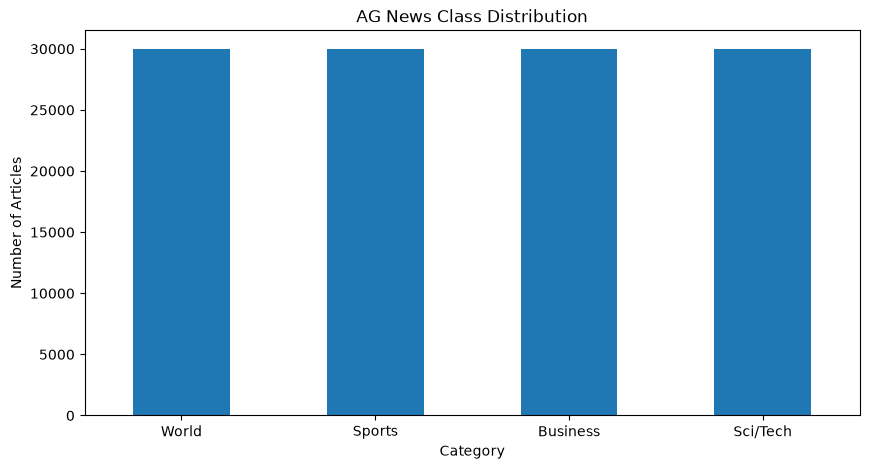

In [ ]:
label_order = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(10, 5))

df1["category"].value_counts().reindex(label_order).plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.title("AG News Class Distribution")
plt.xticks(rotation=0)

plt.show()

In [27]:
df1["word_count"] = df1["text"].apply(lambda x: len(x.split()))
df1[["text", "word_count"]].head()

,text,word_count
0,Wall St. Bears Claw Back Into the Black (Reute...,21
1,Carlyle Looks Toward Commercial Aerospace (Reu...,36
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,36
3,Iraq Halts Oil Exports from Main Southern Pipe...,36
4,"Oil prices soar to all-time record, posing new...",37


In [28]:
df1["word_count"].describe()

count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64

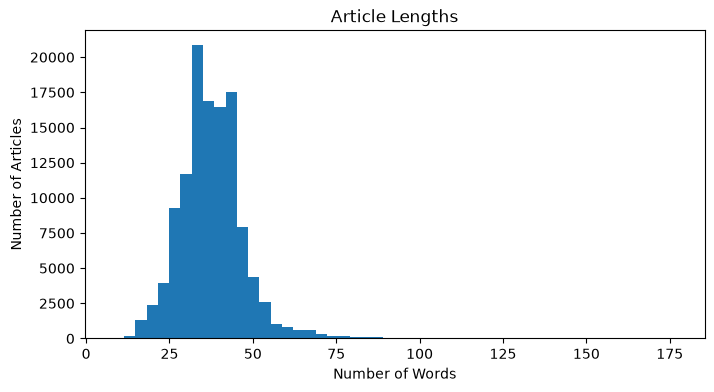

In [30]:
plt.figure(figsize=(8, 4))

plt.hist(df1["word_count"], bins=50)

plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.title("Article Lengths")

plt.show()

In [ ]:
# checl for unique valuea and duplicates
print("Total articles:", len(df1))
print("Unique articles:", df1["text"].nunique())
print("Duplicate articles:", df1["text"].duplicated().sum())

Total articles: 120000
Unique articles: 120000
Duplicate articles: 0


In [ ]:
# check for nulls
df1.isnull().sum()

text          0
label         0
category      0
word_count    0
dtype: int64

In [34]:
pd.crosstab(df1["label"], df1["category"])

category,Business,Sci/Tech,Sports,World
label,,,,
0,0,0,0,30000
1,0,0,30000,0
2,30000,0,0,0
3,0,30000,0,0


In [36]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained( 'google-bert/bert-base-uncased')
token_lengths = [ len(tokenizer.encode(text,add_special_tokens = True))
                 for text in df1['text']]

In [37]:
print("Minimum:", np.min(token_lengths))
print("Maximum:", np.max(token_lengths))
print("Mean:", np.mean(token_lengths))
print("Median:", np.median(token_lengths))

Minimum: 15
Maximum: 379
Mean: 53.16641666666667
Median: 51.0


In [38]:
print(
    np.percentile(
        token_lengths,
        [50, 75, 90, 95, 99]
    )
)

[ 51.  59.  70.  82. 124.]


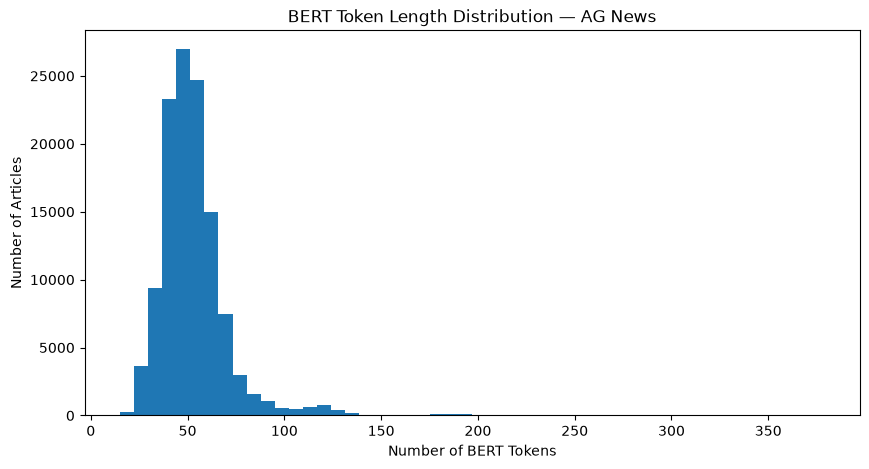

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(token_lengths, bins=50)

plt.xlabel("Number of BERT Tokens")
plt.ylabel("Number of Articles")
plt.title("BERT Token Length Distribution — AG News")

plt.show()